# 1. Importanto os módulos

In [2]:
# Pandas para a análise, manipulação e visualização dos dados
import pandas as pd

# Numpy para manipução dos dados
import numpy as np

# Seaborn e Matplotlib para geração de gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# Os para a acessar os diretórios do sistema
import os

# Salva variável em forma de conjunto de dados
from joblib import dump, load

# 2. Estrutura dos dados

In [ ]:
# Importando o nome dos arquivos
nome_arquivo_csv = os.listdir()[1]

# Importando o arquivo .csv para a Python com Pandas
df = pd.read_csv(nome_arquivo_csv)
df.head()

In [ ]:
# Analisando as informações contidas nas colunas
df.info()

Descrição das variáveis

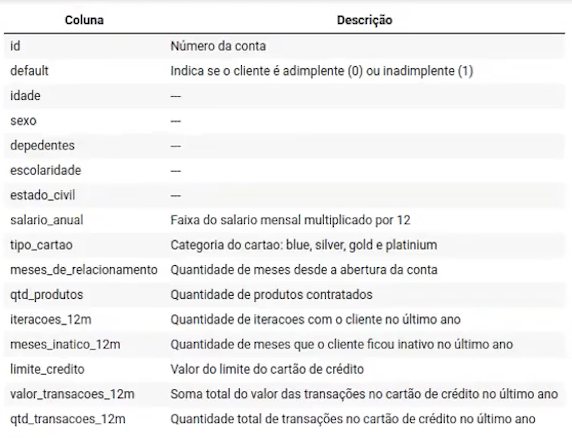

## Corrigindo dados faltantes

Observamos com .info() que todas as variáveis possuem o mesmo número de entradas, o que é interessante. Porém, essa informação está errada pois sabemos que algumas das entradas com a informação "na" são na verdade dados faltantes. Por isso, vamos converter todos os "na" em NuN (np.nan).

In [ ]:
'''
  Laço que itera os nomes das colunas, que serão usadas para selecionar as
  variáveis e convereter, na função lambda, "na" para NuN (np.nan).
'''
for coluna in df.columns:
  df[coluna] = df[coluna].apply(lambda valor: np.nan if valor == "na" else valor)

df.head()

In [ ]:
df.info()

Com isso observamos que as variáveis abaixo tem menos entradas que as demais colunas:
- escolaridade
- estado_civil
- salario_anual

In [ ]:
'''
  Analisando a porcentagem de cobertura dos dados no banco,
  em cada um das variáveis que contém dados faltando
'''
num_escolaridade = df["escolaridade"].notna().sum() / len(df)
num_estado_civil = df["estado_civil"].notna().sum() / len(df)
num_salario_anual = df["salario_anual"].notna().sum() / len(df)

print(f"Escolaridade: {num_escolaridade * 100:.2f}%")
print(f"Estado civil: {num_estado_civil * 100:.2f}%")
print(f"Salario anual: {num_salario_anual * 100:.2f}%")

In [ ]:
print(f"Porcentagem de perda, eliminando os dados faltantes: {round((len(df.dropna()) / len(df) - 1) * -100, 2)}%")

Observamos que a variável com menos dados têm 85% de cobertura do número total de entradas. Entendemos que essa porcentagem pode ser significativa, por isso não vamos apenas remover do conjunto de dados faltantes, o que acarretaria em uma perda de 30%. Para equalizar essa condição, vou **substituir os valores faltando pelas cotegorias já existentens, observando a mesma proporção**.

In [ ]:
# FreqU~encia das categorias na variável escolaridade
round((df['escolaridade'].value_counts(normalize=True)), 2)

In [ ]:
def completa_na_por_frequencia(df: pd.DataFrame, coluna: str) -> pd.DataFrame|str:
  '''
    Função que completa os valores faltantes de uma variável de uma DataFrame
    por valores já presentes na variável, obdesendo a proporção entre eles.
    :param df (pd.DataFrame): DataFrame contendo os dados;
    :param coluna (str): Nome da variável contendo NuN;
    :return df (pd.DataFrame): DataFrame com os dados substituídos;
  '''
  try:
    # Variável que recebe a frequência relativa e o nome das categorias
    data_transforme = df[coluna].value_counts(normalize=True)

    # Número de NuN
    n_amostras = len(df) - len(df[coluna].dropna())

    # Série que é formada pela escolha randômica, usando numpy, das categorias
    categorias = pd.Series(
        data=np.random.choice(
            data_transforme.index,
            p=data_transforme.values,
            size=n_amostras
        ),
        index=df[df[coluna].isna()].index
    )

    # Substituição do NuN pelas categorias
    df.loc[categorias.index, coluna] = categorias.values
    return df
  except Exception as erro:
    return erro

In [ ]:
df = completa_na_por_frequencia(df=df, coluna="escolaridade")
df = completa_na_por_frequencia(df=df, coluna="estado_civil")
df = completa_na_por_frequencia(df=df, coluna="salario_anual")
df.info()

In [ ]:
# FreqU~encia das categorias na variável escolaridade
round((df['escolaridade'].value_counts(normalize=True)), 2)

In [ ]:
'''
  Analisando a porcentagem de cobertura dos dados no banco,
  em cada um das variáveis que contém dados faltando
'''
num_escolaridade = df["escolaridade"].notna().sum() / len(df)
num_estado_civil = df["estado_civil"].notna().sum() / len(df)
num_salario_anual = df["salario_anual"].notna().sum() / len(df)

print(f"Escolaridade: {num_escolaridade * 100:.2f}%")
print(f"Estado civil: {num_estado_civil * 100:.2f}%")
print(f"Salario anual: {num_salario_anual * 100:.2f}%")

### Conclusão

Foi observado que no conjunto de dados, alguns valores estavam faltando. A simples retirada levaria a uma perda de ~30% dos dados, o que julgamos inadequado.

Foi resolvido substituir os valores faltantes pelas mesmas categorias já presentes no conjunto de dados, obdesendo a frequência relativa na variável.

Assim, foi obtido um conjunto de dados sem valores faltantes.

## Tipificação das variáveis

In [ ]:
df.dtypes

Algumas das variáveis não correspondm com as classes (tipos) dos dados usados para armazenar na DataFrame. As variáveis abaixo deveriam ser *category*:

- sexo
- escolaridade
- estado_civil
- salario_anual
- tipo_cartao

As variáveis abaixo deveriam ser *float*:
- limite_credito
- valor_transacoes_12m

Além disso, a variável **default**, que indica o pagamento ou sua falta, deveria ser *bool*.

In [ ]:
# Instanciando uma dicionário com as colunas e as novas classes da DataFrame
novos_tipos = {
    "default":       "bool",
    "sexo":          "category",
    "escolaridade":  "category",
    "estado_civil":  "category",
    "salario_anual": "category",
    "tipo_cartao":   "category",
}
novos_tipos

In [ ]:
# Convertendo para as novas classes usando dicionário
df = df.astype(novos_tipos)

# Convertendo as colunas para float
funcao_convert = lambda x: float(x.replace(".","").replace(",","."))
df["limite_credito"] = df["limite_credito"].apply(funcao_convert)
df["valor_transacoes_12m"] = df["valor_transacoes_12m"].apply(funcao_convert)
df.dtypes

In [ ]:
df.select_dtypes(include=['int64', "float64"]).head()

In [ ]:
df.select_dtypes(exclude=['int64', "float64"]).head()

### Conclusão

O conjunto de dados apresentava algumas colunas que continham informações que não condiziam com a classe (tipo) de variável.

Foram substituídos pelas classes mais propícias por variável.

## Salvamento de dados estruturados

In [ ]:
dump(df, "df_2024-02-09")

# Análise dos dados

In [3]:
# Importando conjunto de dados estruturado
df = load('df_2024-02-09')

## Variáveis quantitativas

In [4]:
# Medidas resumo das variáveis quantitativas
include = ['int64', "float64"]

df.iloc[:,1:].select_dtypes(include=include).describe().T

,count,mean,std,min,25%,50%,75%,max
idade,10127.0,46.325960,8.016814,26.00,41.000,46.00,52.000,73.00
dependentes,10127.0,2.346203,1.298908,0.00,1.000,2.00,3.000,5.00
meses_de_relacionamento,10127.0,35.928409,7.986416,13.00,31.000,36.00,40.000,56.00
qtd_produtos,10127.0,3.812580,1.554408,1.00,3.000,4.00,5.000,6.00
iteracoes_12m,10127.0,2.455317,1.106225,0.00,2.000,2.00,3.000,6.00
meses_inativo_12m,10127.0,2.341167,1.010622,0.00,2.000,2.00,3.000,6.00
limite_credito,10127.0,8632.440165,9088.788041,1438.00,2555.355,4549.42,11068.175,34516.99
valor_transacoes_12m,10127.0,4404.583047,3397.128078,510.16,2155.825,3899.59,4741.310,18484.93
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.00,45.000,67.00,81.000,139.00


In [5]:
def grafico_barras_quantitativo(
    y: str,
    linha: int,
    coluna: int,
    title: str,
    xlabel: str,
    ylabel: str,
  ):
  '''
    Gera uma imagem de gráfico de barras.
    :param y (str): Nome da coluna para o eixo y
    :param linha (int): Coordenada da linha no subplote.
    :param coluna (int): Coordenada da coluna no subplote.
    :param title (str): Título do gráfico no subplote.
    :param xlabel (str): Legenda no eixo x do gráfico no subplote.
    :param ylabel (str): Legenda no eixo y do gráfico no subplote.
    :return (plt.axis): Retorna o gráfico em um eixo de uma figura com subplotes
  '''
  f = sns.barplot(
      palette="Paired",
      y=y,
      hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
      data=df,
      ax=eixos[linha][coluna]
  )

  f.set(
      title=title,
      xlabel=xlabel,
      ylabel=ylabel,
  )
  return f

In [6]:
# Objeto que contêm o nome das variáveis quantitativas
colunas_quantitativas = df.iloc[:,1:].select_dtypes(include=include).columns
colunas_quantitativas

Index(['idade', 'dependentes', 'meses_de_relacionamento', 'qtd_produtos',
       'iteracoes_12m', 'meses_inativo_12m', 'limite_credito',
       'valor_transacoes_12m', 'qtd_transacoes_12m'],
      dtype='object')

In [7]:
# Lista com dicionários contendo as informações para serem inseridas no gráfico
variavveis_para_grafico = [
    {'y':     colunas_quantitativas[0],
    'linha':  0,
    'coluna': 0,
    'title': 'Idade',
    'xlabel': colunas_quantitativas[0],
    'ylabel': 'Idades em Anos',},

     {'y':     colunas_quantitativas[1],
    'linha':  0,
    'coluna': 1,
    'title': 'Dependentes',
    'xlabel': colunas_quantitativas[1],
    'ylabel': 'Número de Dependentes',},

     {'y':     colunas_quantitativas[2],
    'linha':  0,
    'coluna': 2,
    'title': 'Meses de Relacionamento',
    'xlabel': colunas_quantitativas[2],
    'ylabel': 'Número de Meses',},

    {'y':     colunas_quantitativas[3],
    'linha':  1,
    'coluna': 0,
    'title': 'Quant. de Produtos',
    'xlabel': colunas_quantitativas[3],
    'ylabel': 'Número de Produtos',},

    {'y':     colunas_quantitativas[4],
    'linha':  1,
    'coluna': 1,
    'title': 'Quant. de Iterações com o Cliente (últimos 12 meses)',
    'xlabel': colunas_quantitativas[4],
    'ylabel': 'Número de Iterações',},

    {'y':     colunas_quantitativas[5],
    'linha':  1,
    'coluna': 2,
    'title': 'Meses de Inatividade (últimos 12 meses)',
    'xlabel': colunas_quantitativas[5],
    'ylabel': 'Número de Meses',},

    {'y':     colunas_quantitativas[6],
    'linha':  2,
    'coluna': 0,
    'title': 'Limite de Crédito',
    'xlabel': colunas_quantitativas[6],
    'ylabel': 'Limitee',},

    {'y':     colunas_quantitativas[7],
    'linha':  2,
    'coluna': 1,
    'title': 'Valor das Transações (últimos 12 meses)',
    'xlabel': colunas_quantitativas[7],
    'ylabel': 'Valor médio das Transações',},

    {'y':     colunas_quantitativas[8],
    'linha':  2,
    'coluna': 2,
    'title': 'Quant. de Transações (últimos 12 meses)',
    'xlabel': colunas_quantitativas[8],
    'ylabel': 'Número de Transações',},
]

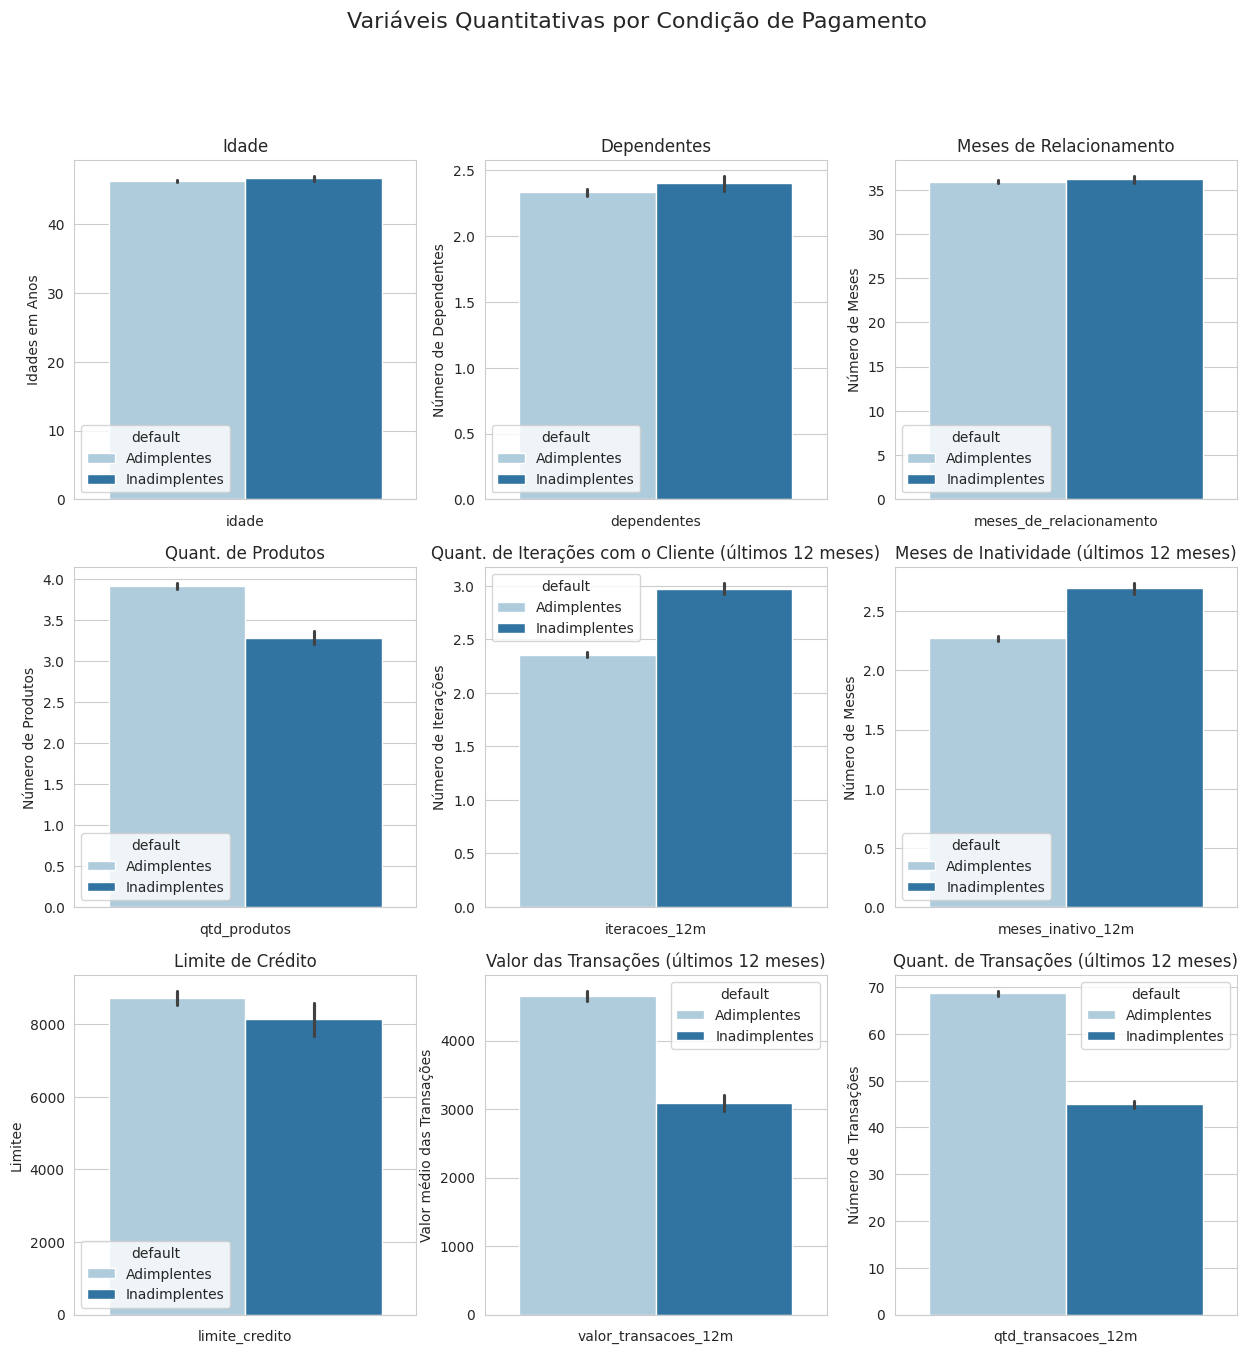

In [8]:
# Plotagem dos gráficos com as variáveis quantitativas
sns.set_style('whitegrid')

figura, eixos = plt.subplots(3,3, figsize=(15,15))

plt.suptitle('Variáveis Quantitativas por Condição de Pagamento', size=16)

for valores in variavveis_para_grafico:
  grafico_barras_quantitativo(**valores)

# plt.savefig("variaveis_quantitativas_2024-02-09.png", dpi=300, bbox_inches='tight', )
plt.show()

### Conclusão 1.

Algumas das variáveis quantitativas parecem não ser importantes para explicar a variável dependente de default. Adimplentes e inadimplentes tem a pouca variação na média de *idade*, no *número de dependentes* e no *número de meses que são clientes* da instituição.

Já as varíaveis abaixo, parecem ser diferentes entre clientes adimplentes e inadimplentes.

- *Quantidade de produtos adquiridos*
  
  Adimplentes adquirem **mais** produtos que inadimplentes

- *Quantidade de iterações da instituição com o cliente (12 meses)*
  
  A instituições iterage **menos** com adimplentes do que com inadimplentes

- *Meses de inatividade do cliente (12 meses)*
  
  Adimplentes são **menos** ativos na instituição do que inadimplentes

- *Valor das transações (12 meses)*
  
  Adimplentes transacionaram **mais** do que inadimplentes

- *Quantidade de transações (12 meses)*
  
  Adimplentes transacionaram **em maior montante** do que inadimplentes


Uma variável que mostra um comportamento limitrofe é a de *Limite de crédito* recebido pelo cliente, onde o adimplentes tem menor *limite de crédito* que inadimplentes, porém essa diferença não é clara.


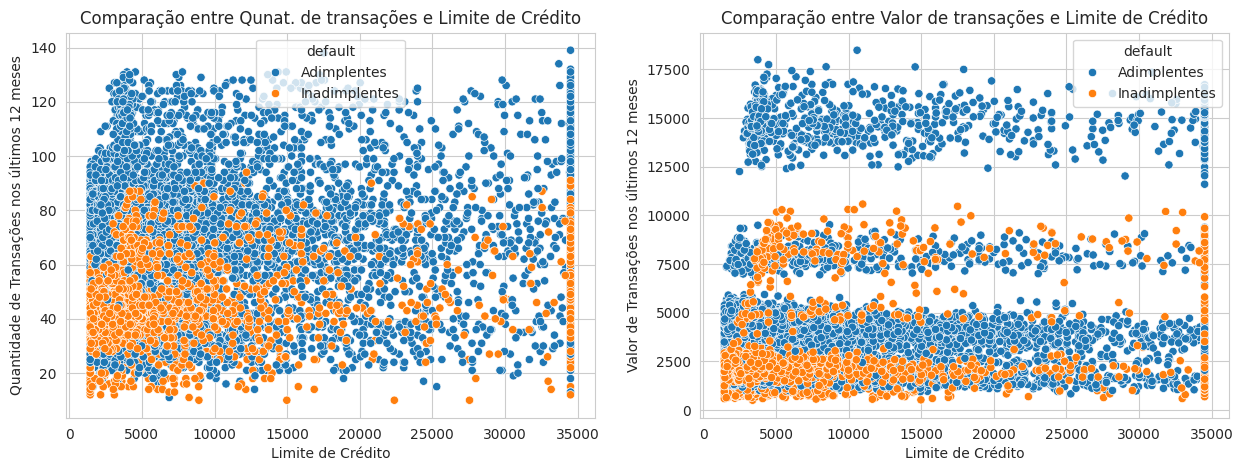

In [9]:
figura, eixos = plt.subplots(1,2, figsize=(15,5))

f = sns.scatterplot(
    x='limite_credito',
    y='qtd_transacoes_12m',
    hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
    data=df,
    ax=eixos[0]
)
f.set(
    title="Comparação entre Qunat. de transações e Limite de Crédito",
    xlabel="Limite de Crédito",
    ylabel="Quantidade de Transações nos últimos 12 meses",
)

f = sns.scatterplot(
    x='limite_credito',
    y='valor_transacoes_12m',
    hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
    data=df,
    ax=eixos[1]
)
f.set(
    title="Comparação entre Valor de transações e Limite de Crédito",
    xlabel="Limite de Crédito",
    ylabel="Valor de Transações nos últimos 12 meses",
)

plt.show()

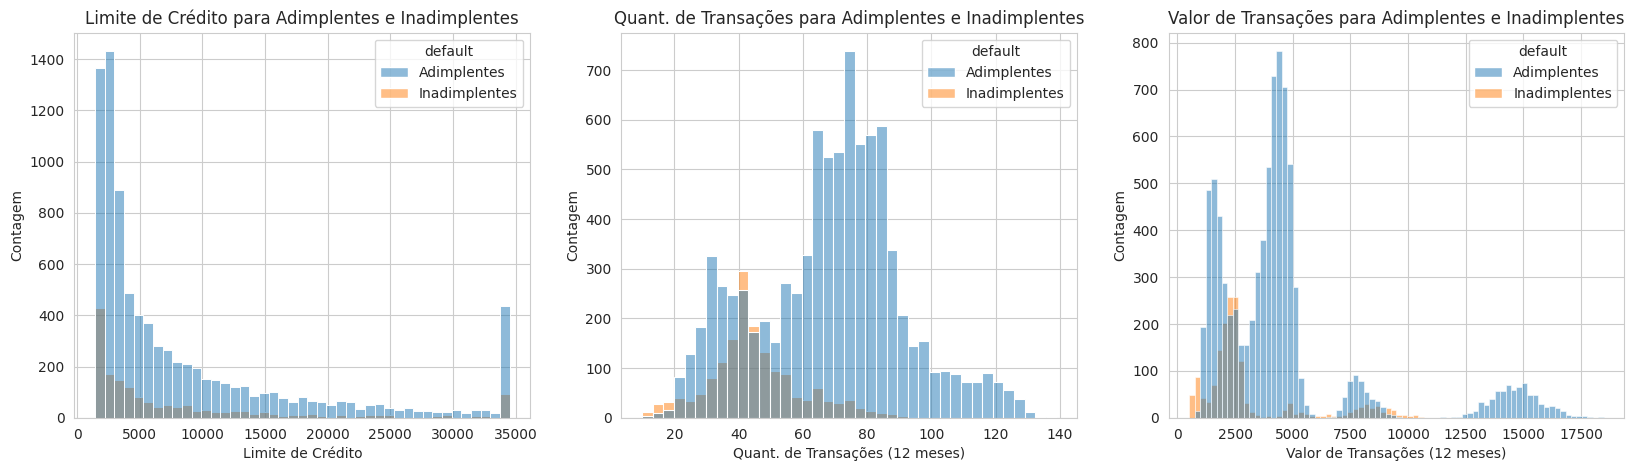

In [10]:
figura, eixos = plt.subplots(1,3, figsize=(20,5))

f = sns.histplot(
    x='limite_credito',
    hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
    data=df,
    ax=eixos[0]
)
f.set(
    title="Limite de Crédito para Adimplentes e Inadimplentes",
    xlabel="Limite de Crédito",
    ylabel="Contagem",
)

f = sns.histplot(
    x='qtd_transacoes_12m',
    hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
    data=df,
    ax=eixos[1]
)
f.set(
    title="Quant. de Transações para Adimplentes e Inadimplentes",
    xlabel="Quant. de Transações (12 meses)",
    ylabel="Contagem",
)

f = sns.histplot(
    x='valor_transacoes_12m',
    hue=df['default'].apply(lambda x: 'Inadimplentes' if x else 'Adimplentes'),
    data=df,
    ax=eixos[2]
)
f.set(
    title="Valor de Transações para Adimplentes e Inadimplentes",
    xlabel="Valor de Transações (12 meses)",
    ylabel="Contagem",
)

plt.show()

### Conclusão 2.

Apesar de observarmos que muitos clientes que transacionam mais e em maiores valores são adimplentes, isso não se relaciona com o limite de crédito.

Clientes inadimplentes possuem um limite de crédito semelhante aos adimplentes, mesmo transacionando menos e em menor valores.

## Variáveis Qualitativas

In [11]:
# Variáveis qualitativas
df.iloc[:,1:].select_dtypes(exclude=include).describe().T

,count,unique,top,freq
default,10127,2,False,8500
sexo,10127,2,F,5358
escolaridade,10127,5,mestrado,3662
estado_civil,10127,3,casado,5064
salario_anual,10127,5,menos que $40K,3973
tipo_cartao,10127,4,blue,9436


É indicado pela LGPD que alguns dados são “sensíveis”, que são os que revelam origem racial ou étnica, convicções religiosas ou filosóficas, opiniões políticas, filiação sindical, questões genéticas, biométricas e sobre a saúde ou a vida sexual de uma pessoa.

Assim, no nosso conjunto de dados, vamos excluir sexo, como indicado.


In [12]:
del df['sexo']
# Variáveis qualitativas
df.iloc[:,1:].select_dtypes(exclude=include).describe().T

,count,unique,top,freq
default,10127,2,False,8500
escolaridade,10127,5,mestrado,3662
estado_civil,10127,3,casado,5064
salario_anual,10127,5,menos que $40K,3973
tipo_cartao,10127,4,blue,9436


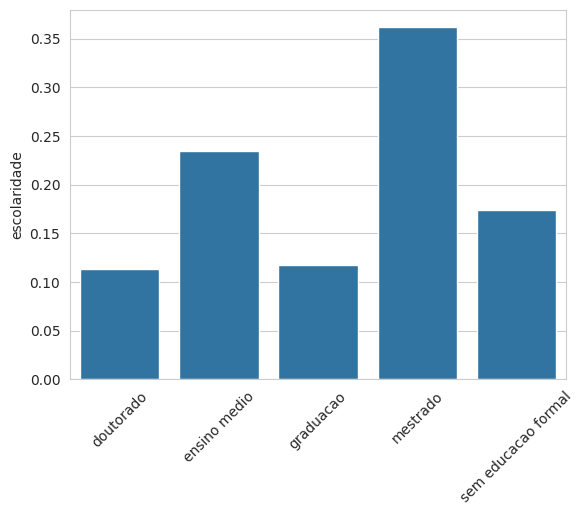

In [13]:
sns.barplot(
  df['escolaridade'].value_counts(normalize=True)
)
plt.xticks(rotation=45)
plt.show()

In [32]:
def formata_titulo(valor: str) -> str:
  valor = valor.replace("_", " ")
  valor = valor.title()
  return valor

In [15]:
def melt_df(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
  coluna_adimplentes = df[df['default'] == True][coluna].value_counts(normalize=True)
  coluna_inadimplentes  = df[df['default'] == False][coluna].value_counts(normalize=True)

  df_coluna = pd.concat([coluna_adimplentes, coluna_inadimplentes], axis=1)
  df_coluna.index = df_coluna.index.str.title()
  df_coluna.reset_index(inplace=True)
  df_coluna.columns = ['Coluna', 'Adimplentes','Inadimplentes']
  df_coluna_melted = df_coluna.melt(id_vars='Coluna').rename(columns=str.title)
  df_coluna_melted.columns = [formata_titulo(coluna), 'Default','Valores']
  return df_coluna_melted

In [46]:
def grafico_barras_qualitativo(
    df: pd.DataFrame,
    coluna: str,
    lin: int,
    col: int
  ):
  f = sns.barplot(
      palette="Paired",
      x=formata_titulo(coluna),
      y='Valores',
      hue='Default',
      data=melt_df(df, coluna),
      ax=eixos[lin][col]
  )
  f.set(
    title=formata_titulo(coluna),
    ylabel='Frequência',
    xlabel=formata_titulo(coluna),
  )

  f.tick_params(axis='x', labelrotation = 45)
  return f

In [47]:
colunas = df.iloc[:,2:].select_dtypes(exclude=include).columns
colunas

Index(['escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao'], dtype='object')

In [52]:
# Lista com dicionários contendo as informações para serem inseridas no gráfico
variavveis_para_grafico = [
    {
        "df": df,
        "coluna": colunas[1],
        "lin": 0,
        "col": 0,
    },
    {
        "df": df,
        "coluna": colunas[3],
        "lin": 0,
        "col": 1,
    },
    {
        "df": df,
        "coluna": colunas[0],
        "lin": 1,
        "col": 0,
    },
    {
        "df": df,
        "coluna": colunas[2],
        "lin": 1,
        "col": 1,
    },
]

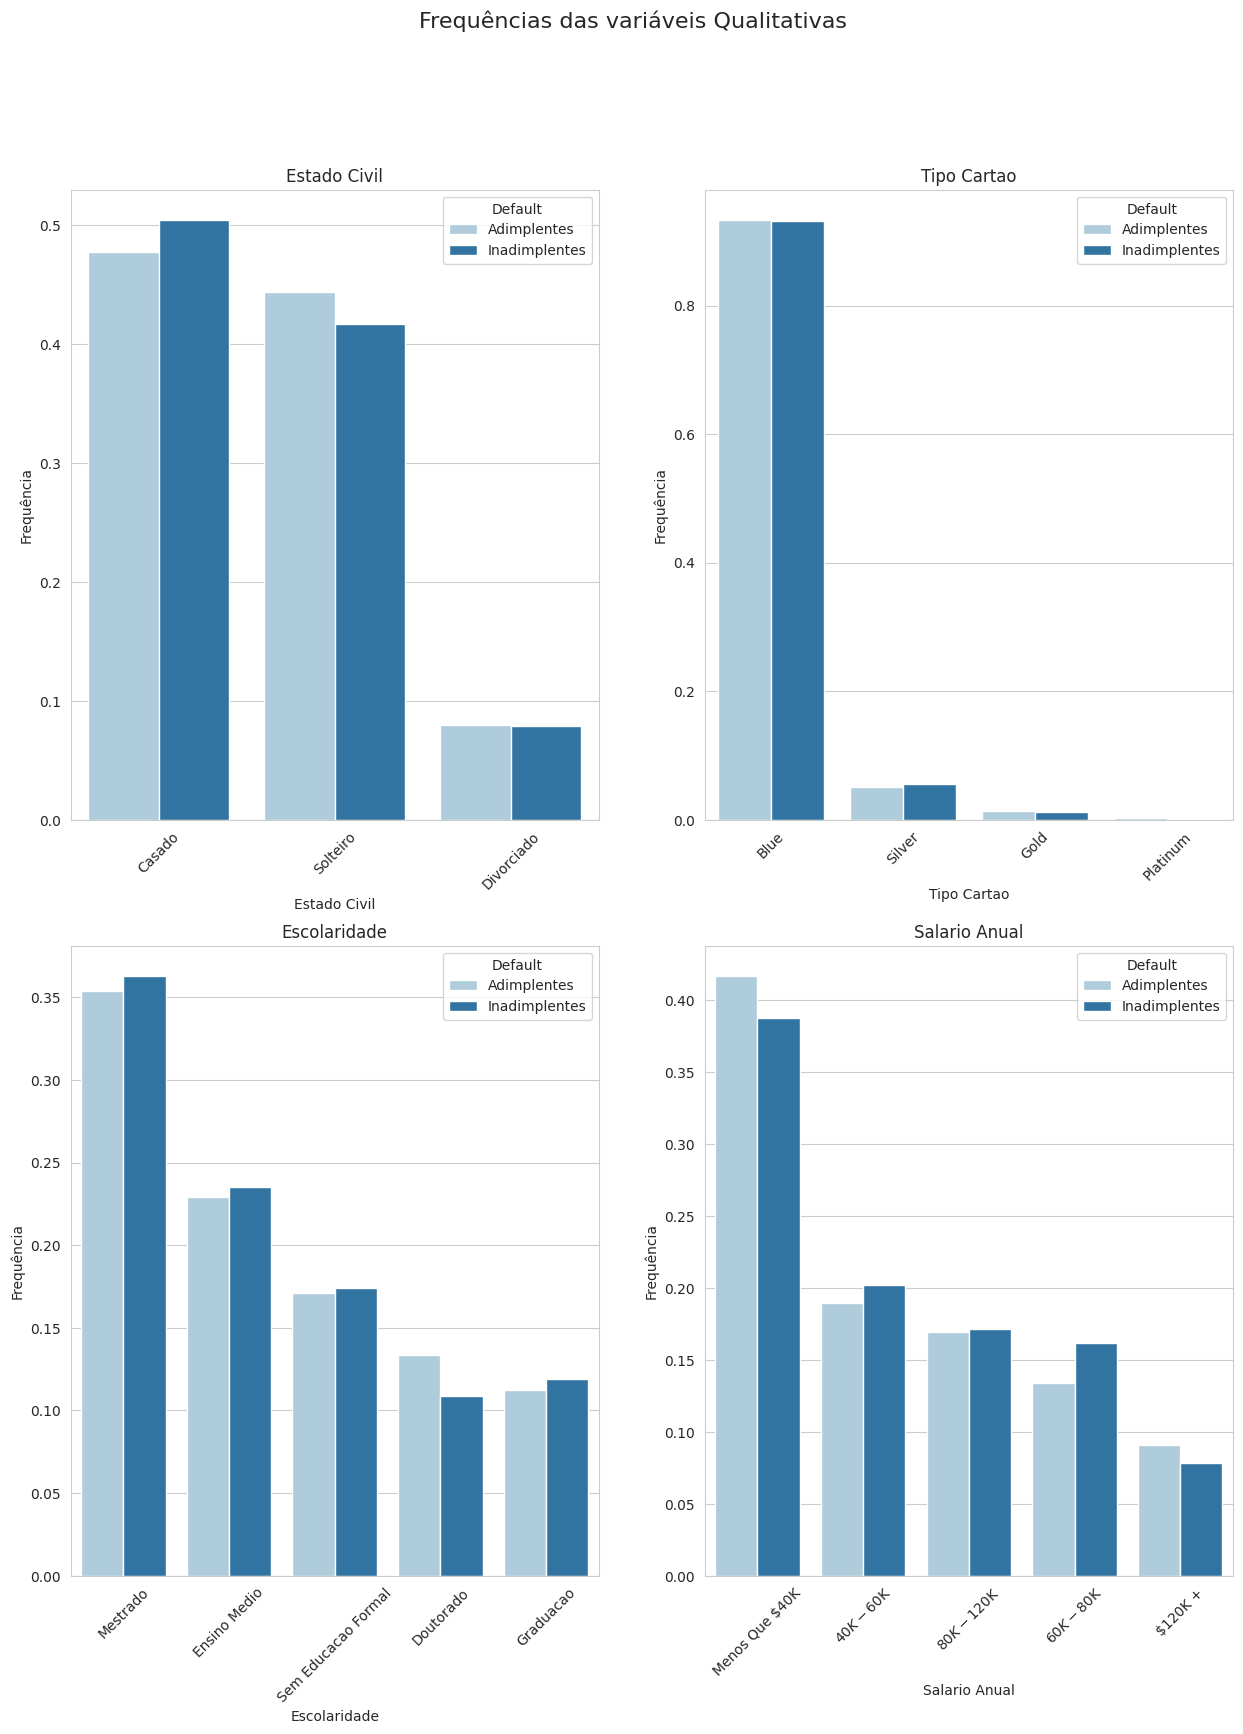

In [56]:
figura, eixos = plt.subplots(2,2, figsize=(15,18))

plt.suptitle('Frequências das variáveis Qualitativas', size=16)

for parametros in variavveis_para_grafico:
  grafico_barras_qualitativo(**parametros)

plt.show()

### Conclusão